# Viz_GDGU_loc — Result Visualization

Reads CSV + JSON from `results/<DATE_FOLDER>/` (produced by `train.py` or `run_experiments.py`).  
All figures are saved to the same date folder as PDF.  
**Edit Cell 1 to set paths and style overrides.**

In [1]:
# Cell 1 — Config (edit here)
# ============================================================
DATE_FOLDER = '2026-04-15_01'   # ← change to your results folder name
BUS_SYSTEM  = '34bus'            # '34bus' or '123bus'

# Style overrides — passed to apply_style(); see src/visualization.py STYLE dict
STYLE_OVERRIDES = {
    # Font — Times New Roman for all text
    'font_family':   'Times New Roman',
    'fs_label':      26,
    'fs_tick':       20,
    'fs_legend':     20,
    'fs_subtitle':   22,
    'fs_annotation': 18,

    # Colors — 5 methods (Original, GDGU, GIF, IDEA, Retrain)
    'colors': {
        'Original': "#C7CADE",
        'GDGU':     "#F7AC53",
        'GIF':      "#52AADC",
        'IDEA':     "#EC6E66",
        'Retrain':  "#6ADD6E",
    },
    'markers': {
        'Original': 'o',
        'GDGU':     's',
        'GIF':      'D',
        'IDEA':     'P',
        'Retrain':  '^',
    },
    'ideal_line_color': 'red',
    'grid_alpha':       0.3,
    'bar_alpha':        0.85,
    'bar_edge_color':   'black',
    'bar_edge_width':   0.5,
    'fill_alpha':       0.15,

    # Save
    'save_fmt': 'pdf',
    'save_dpi': 300,
}

In [2]:
# Cell 2 — Setup
import sys, json
from pathlib import Path

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from src.visualization import (apply_style, load_results, plot_all,
                                plot_khop_comparison, plot_khop_forget_size)

%load_ext autoreload
%autoreload 2

apply_style(STYLE_OVERRIDES)

# All outputs (CSV, JSON, figures) live in the same date folder
RESULTS_DIR = PROJECT_ROOT / 'results' / DATE_FOLDER
df, scenarios, backbones = load_results(str(RESULTS_DIR), BUS_SYSTEM)

# Show metadata from epoch logs if available
log_path = RESULTS_DIR / f'{BUS_SYSTEM}_epoch_logs.json'
if log_path.exists():
    with open(log_path) as f:
        meta = json.load(f).get('_metadata', {})
    print(f"\nTimestamp : {meta.get('timestamp', 'N/A')}")
    print(f"Device   : {meta.get('device', 'N/A')}")
    d = meta.get('data', {})
    print(f"Graphs={d.get('n_graphs')}, Nodes={d.get('n_nodes')}, "
          f"Features={d.get('n_feat')}, EVCS={d.get('n_evcs')}")
    for name, n_params in meta.get('model_params', {}).items():
        print(f"  {name}: {n_params:,} params")

Loaded 1800 rows from /home/Nanhong147/1P_WTT_NVD/Projects/4-GU_EV_loc/results/2026-04-15_01/34bus_results_raw.csv
  Backbones : ['GAT', 'GCN', 'GIN']
  Scenarios : ['S1-0', 'S1-1', 'S1-2', 'S1-3', 'S2-0', 'S2-1', 'S2-2', 'S2-3', 'S3-0', 'S3-1', 'S3-2', 'S3-3']
  Methods   : ['GDGU', 'GIF', 'IDEA', 'Original', 'Retrain']

Timestamp : 2026-04-15 10:25:48
Device   : cuda:1
Graphs=2000, Nodes=37, Features=24, EVCS=3
  GAT: 379,011 params
  GCN: 70,275 params
  GIN: 119,811 params


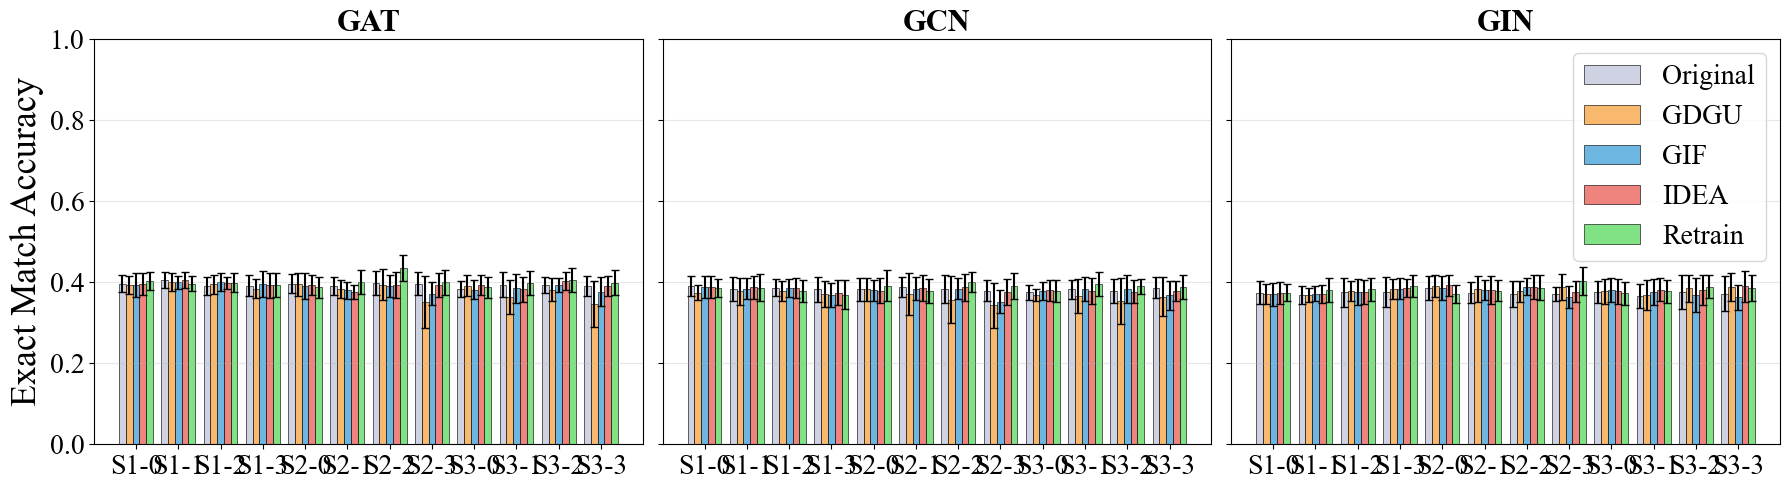

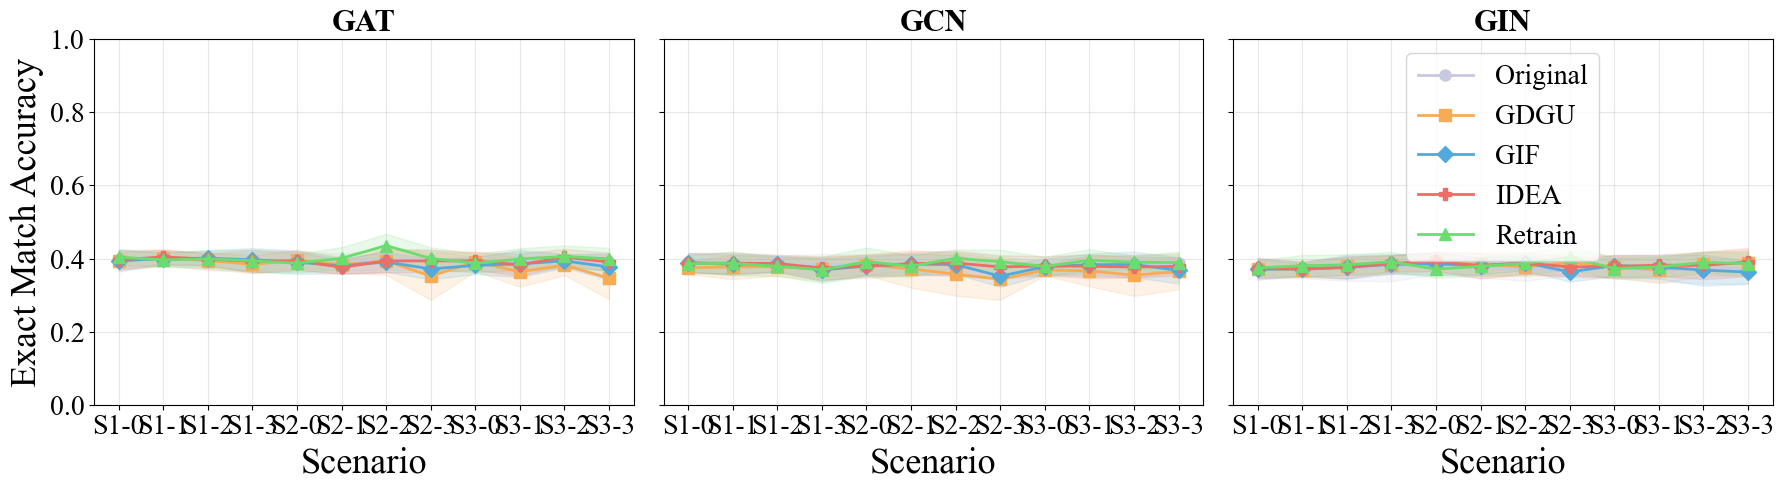

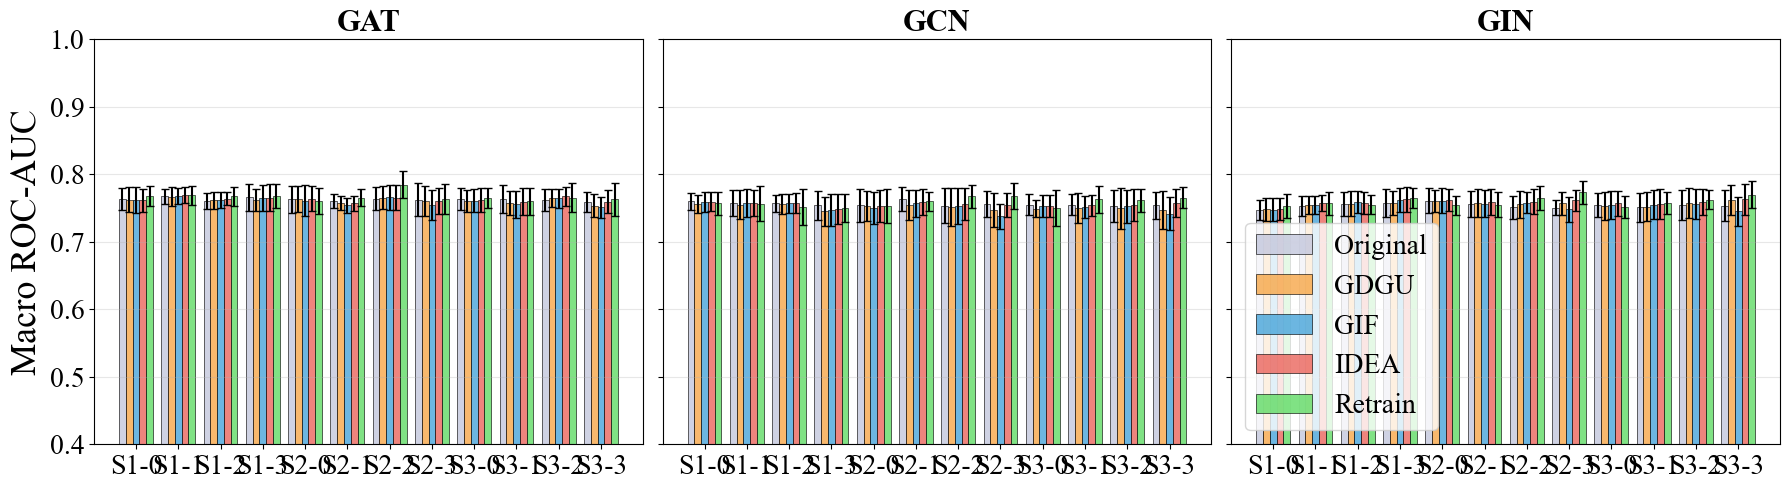

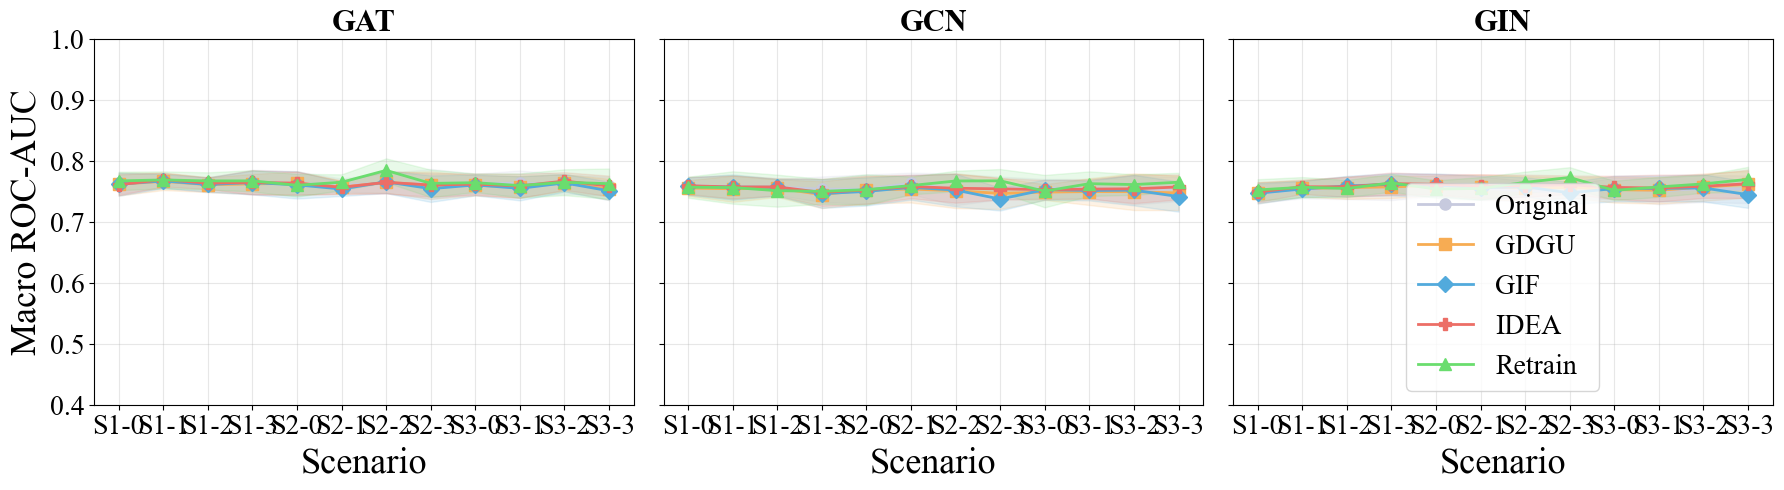

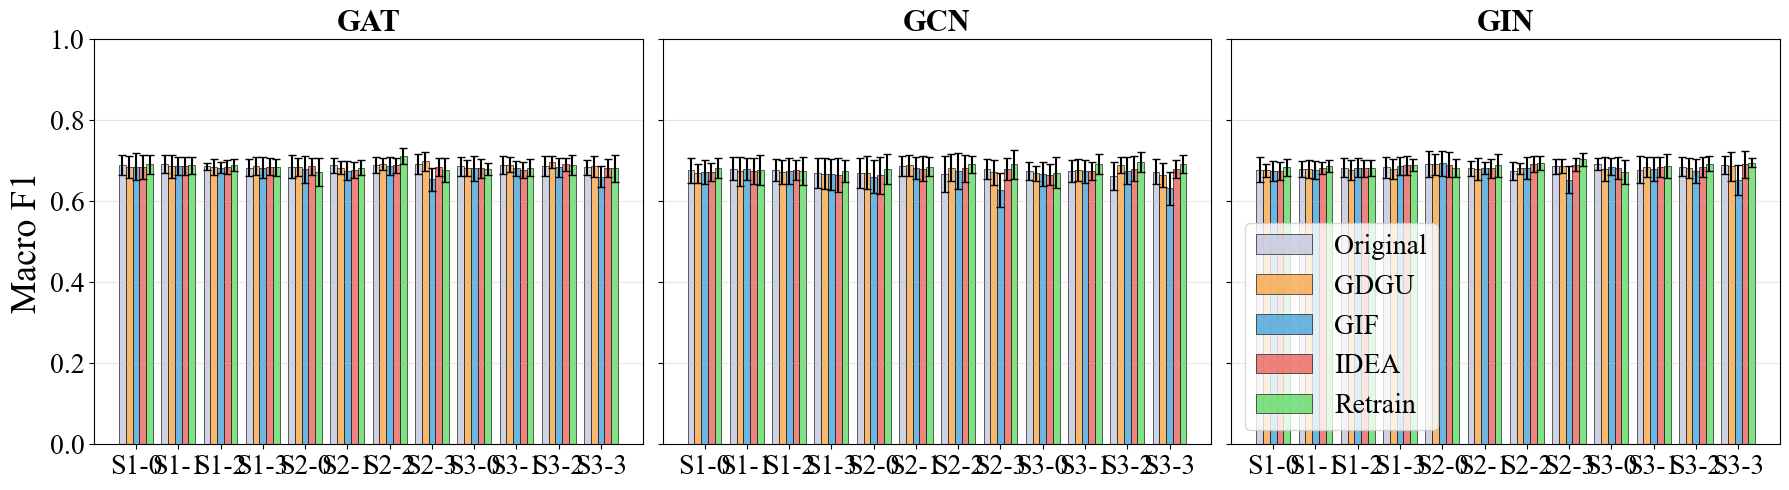

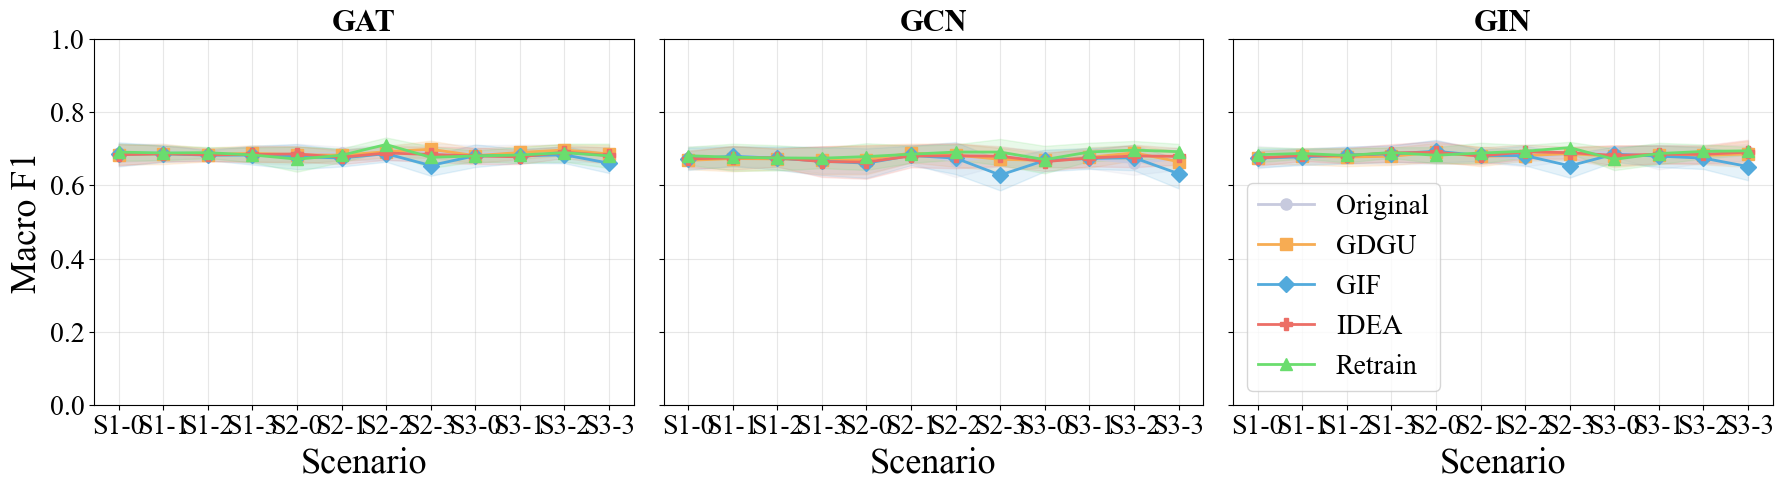

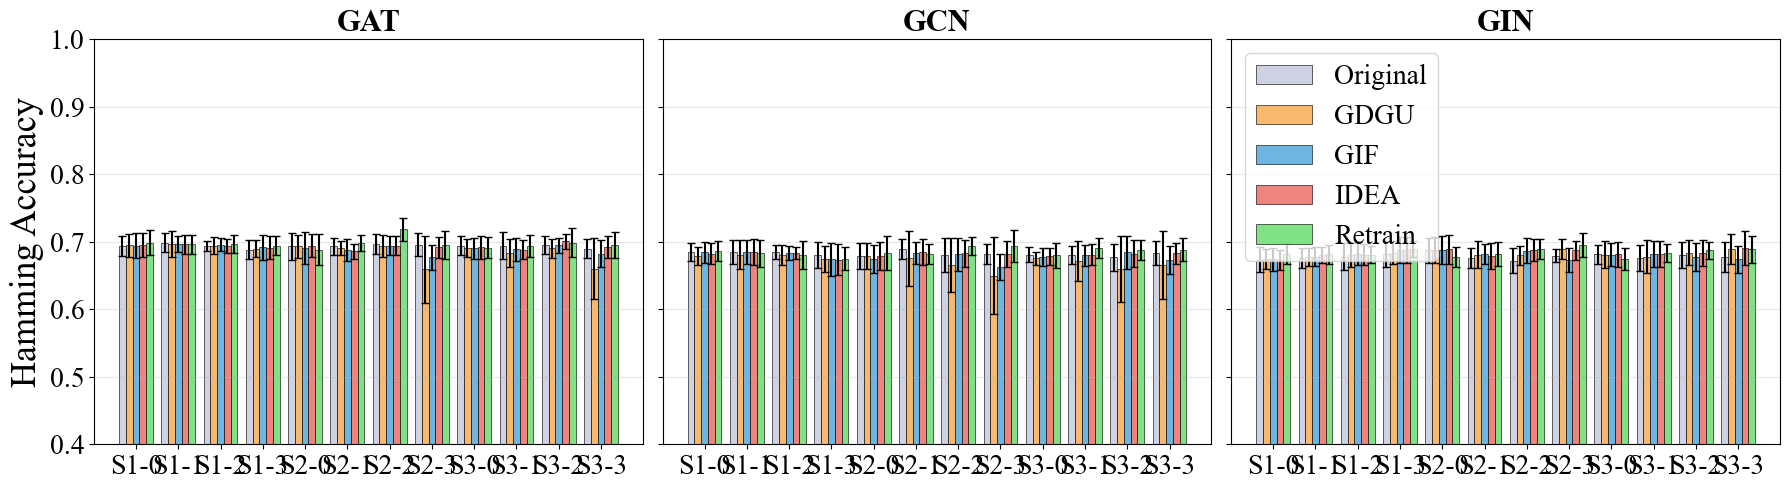

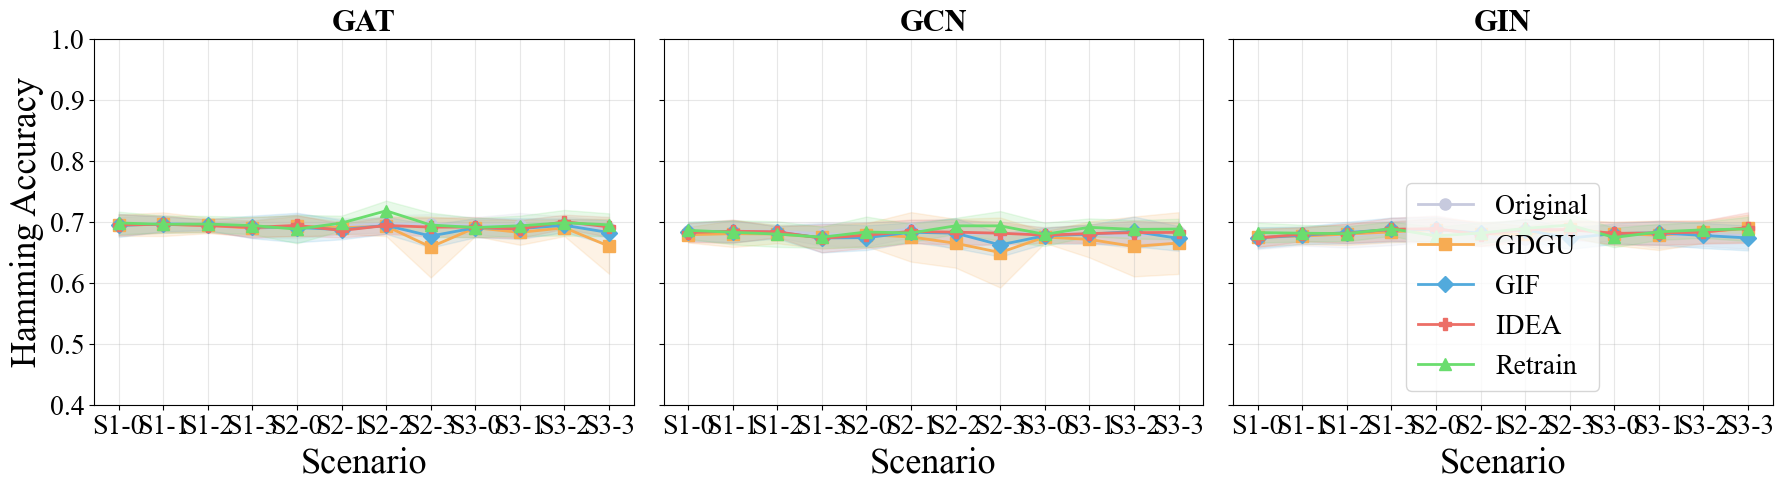

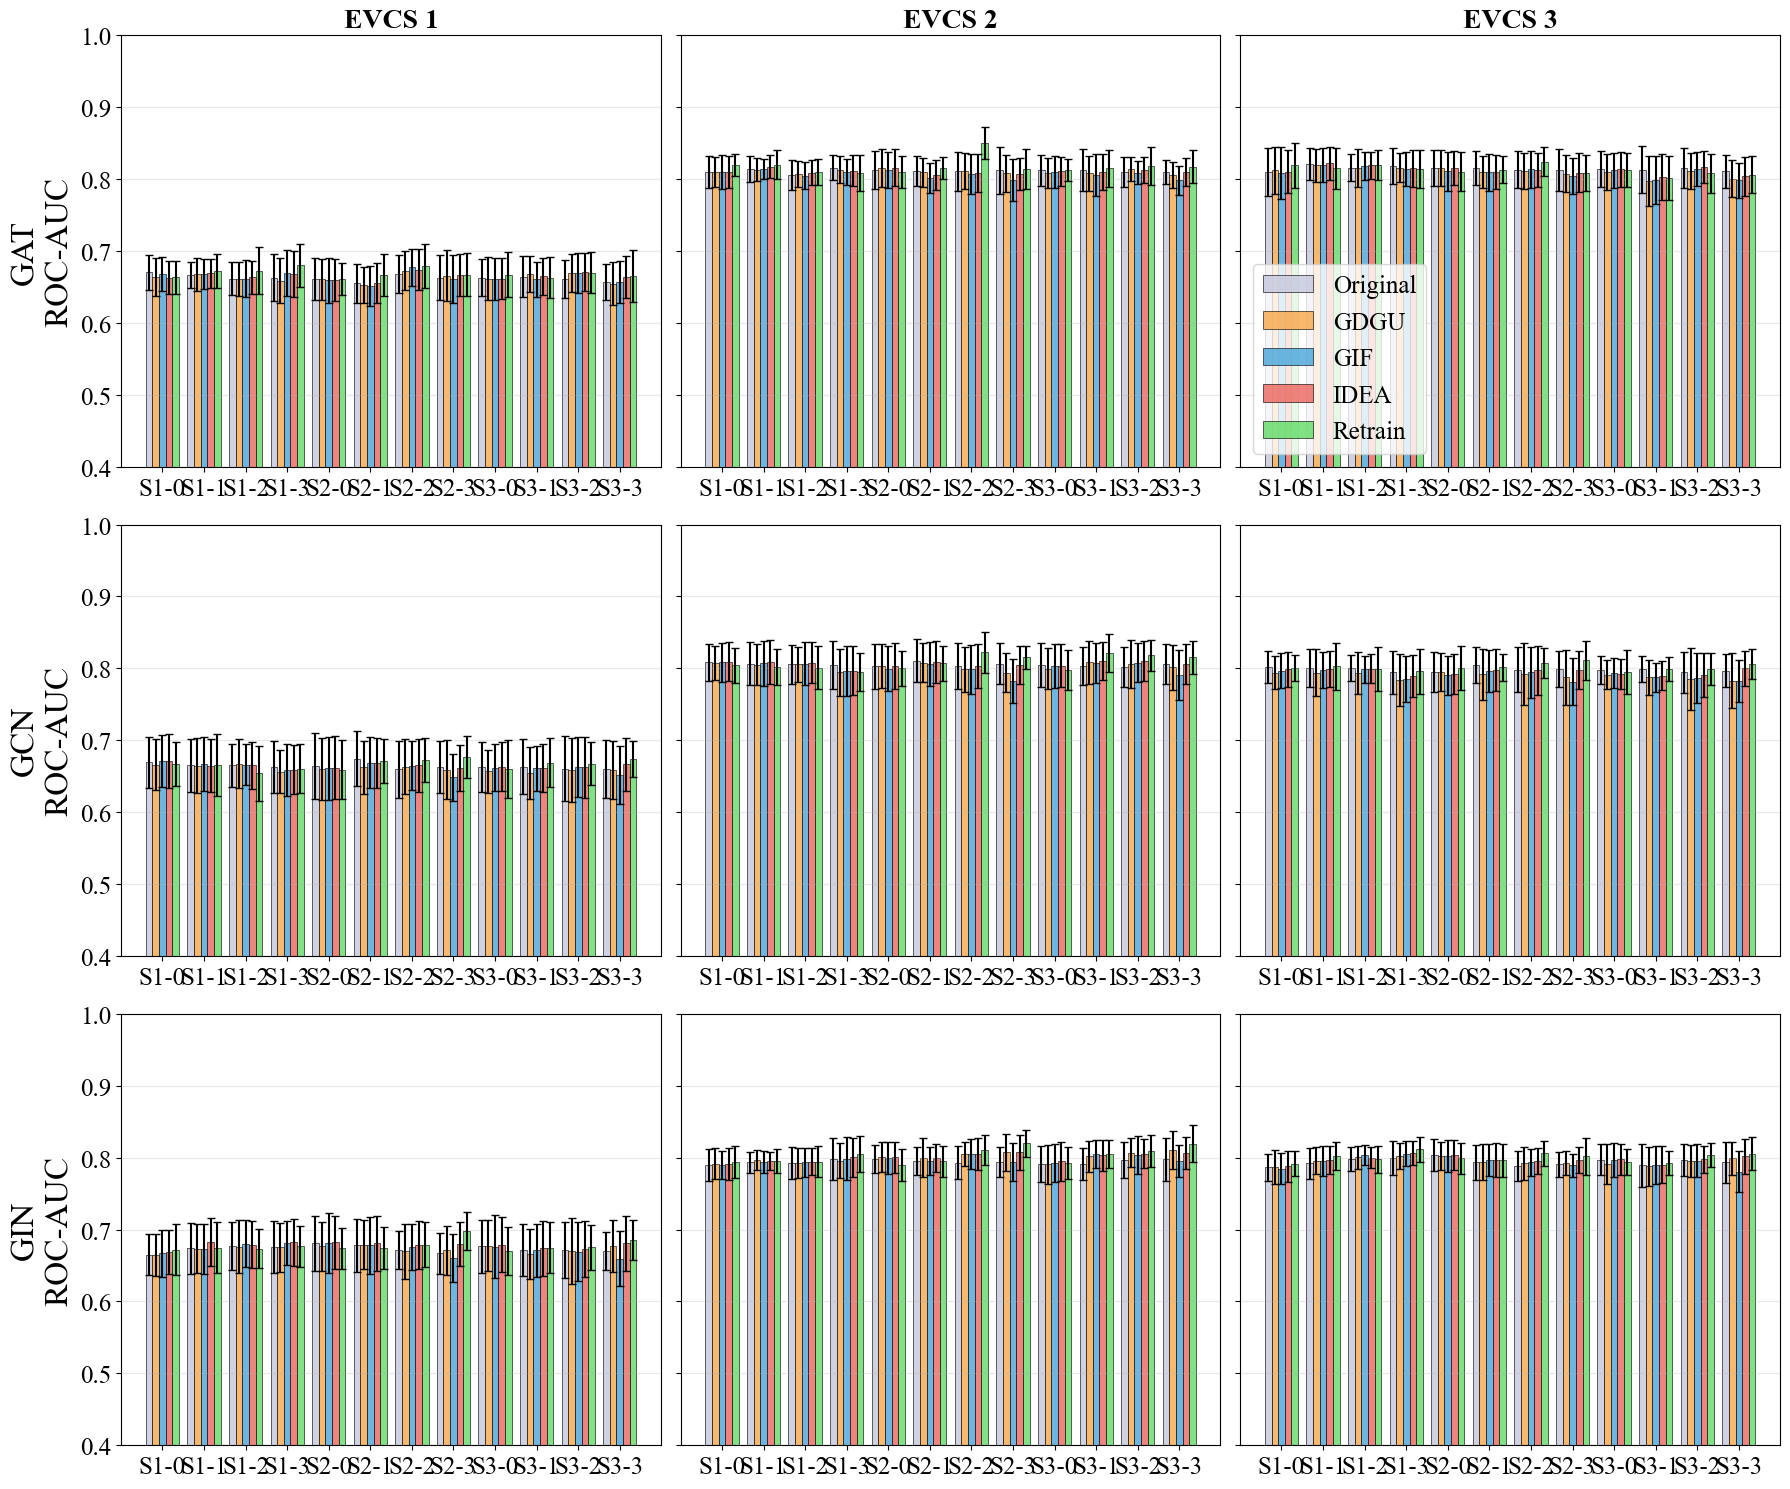

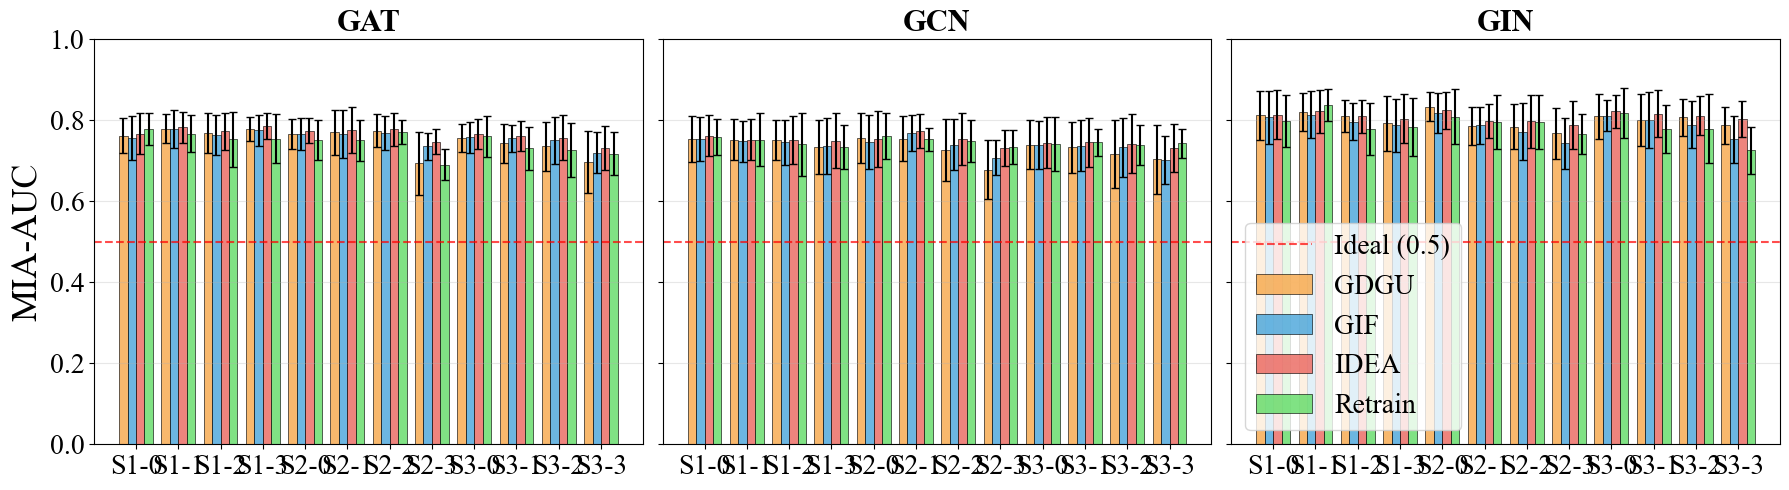

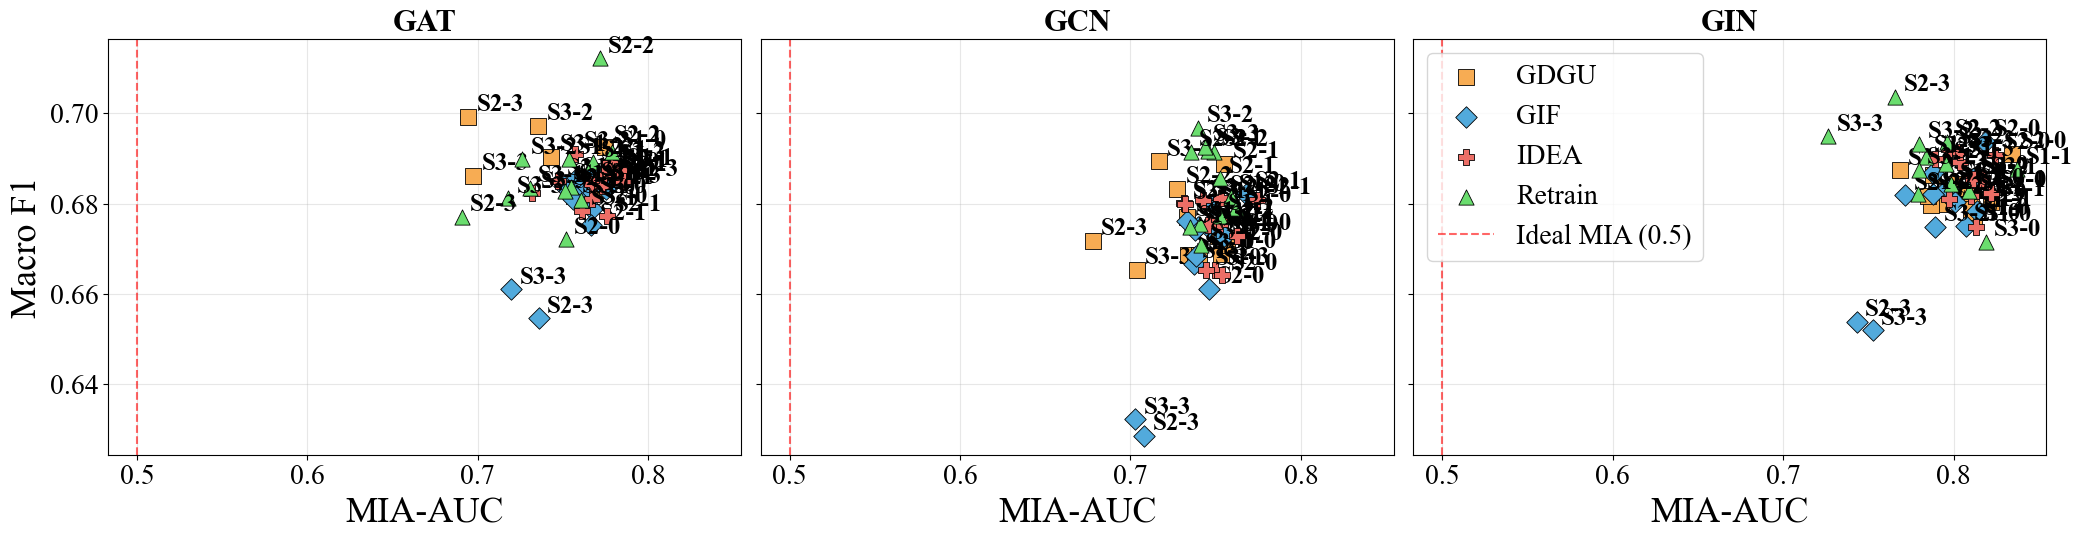

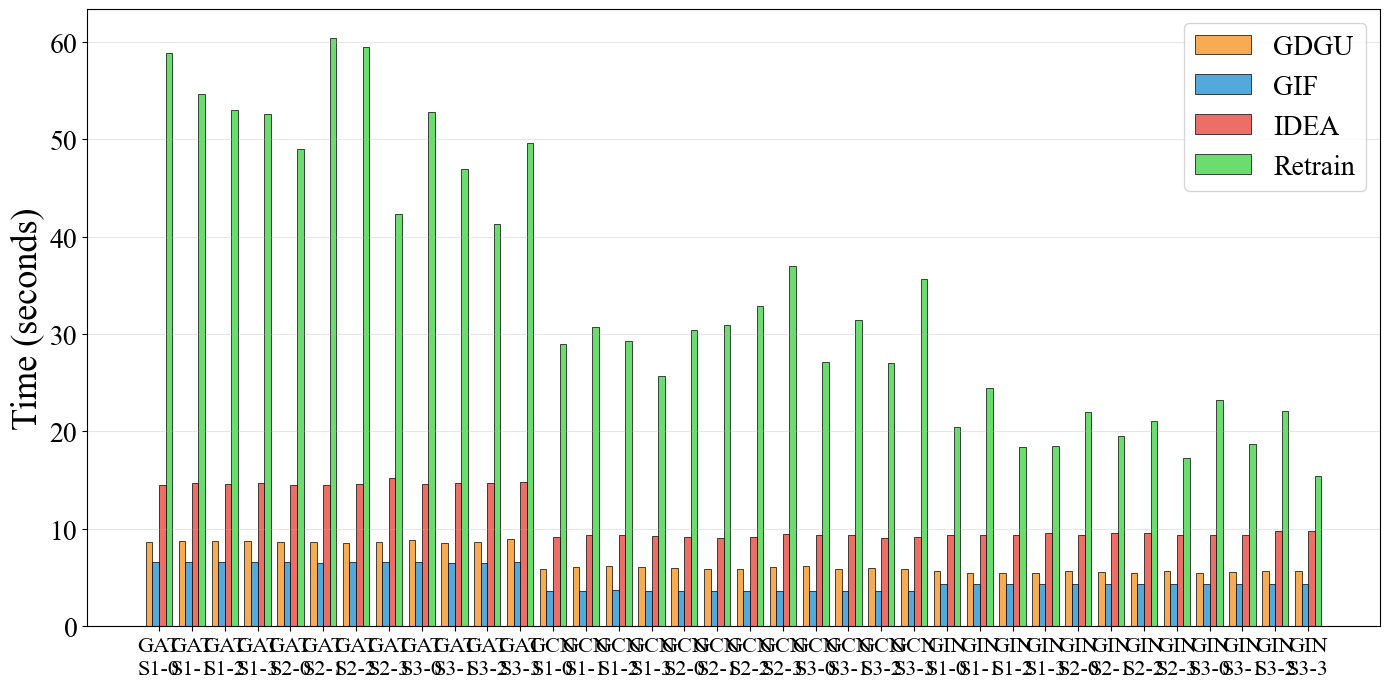

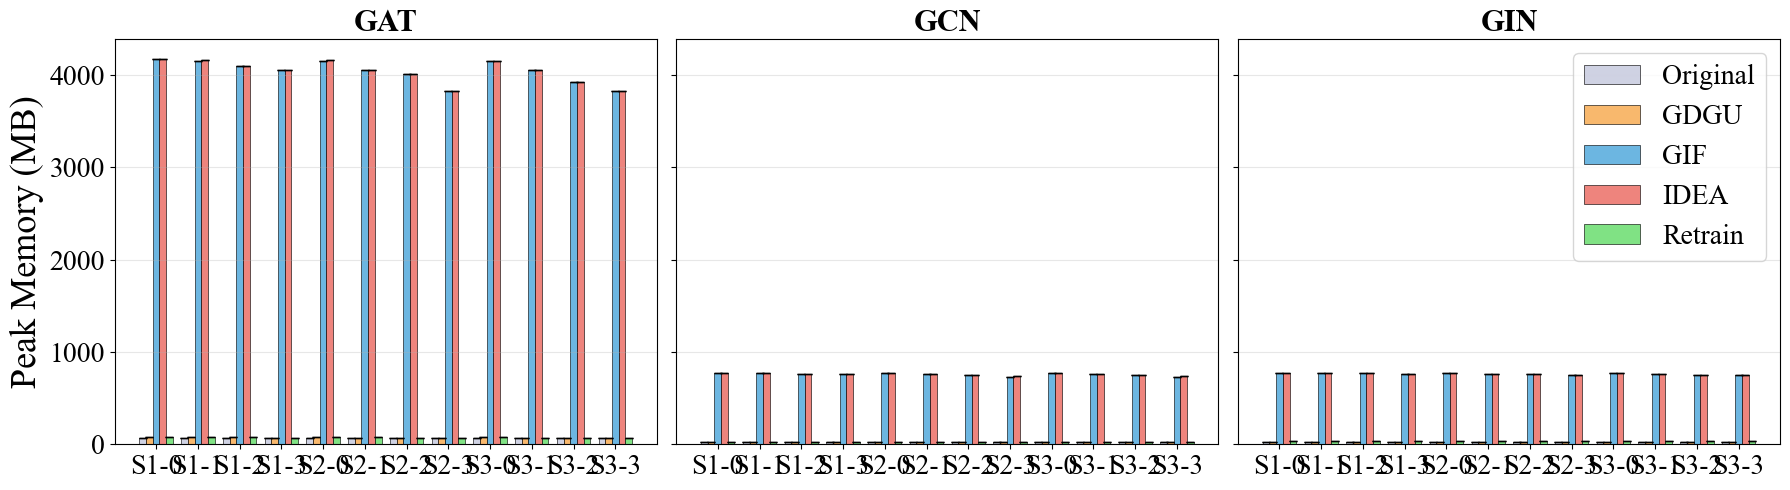

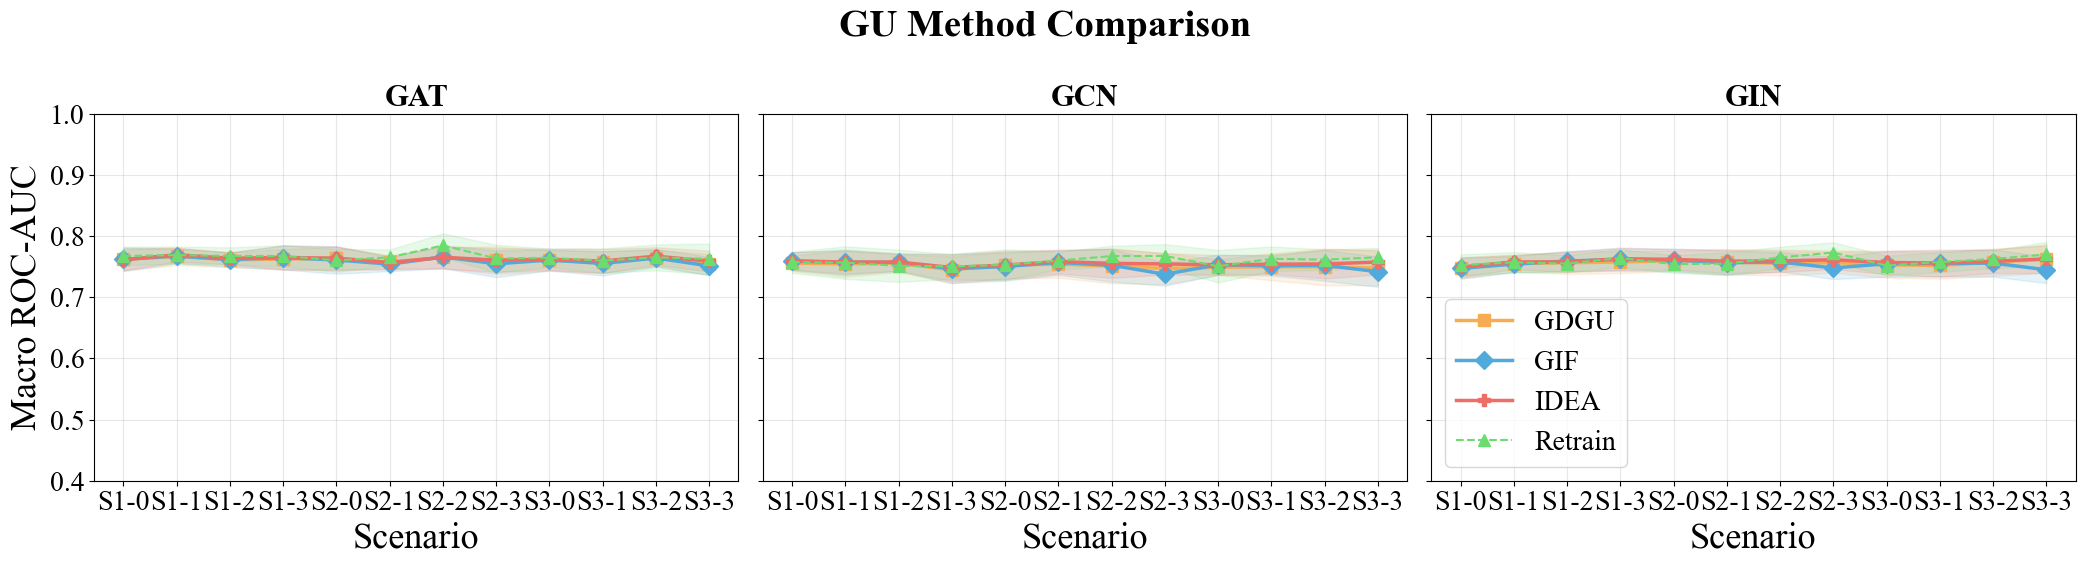

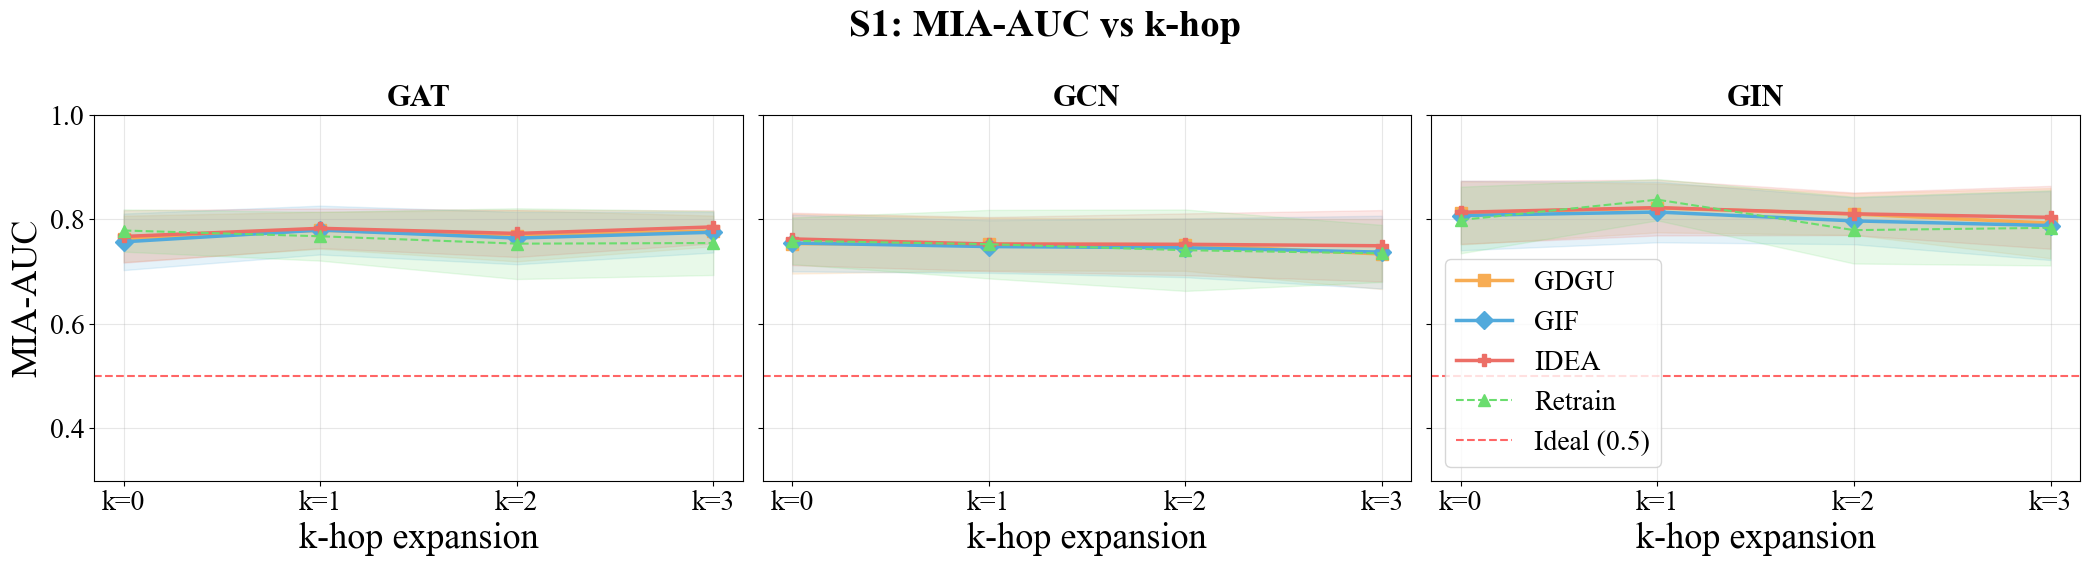

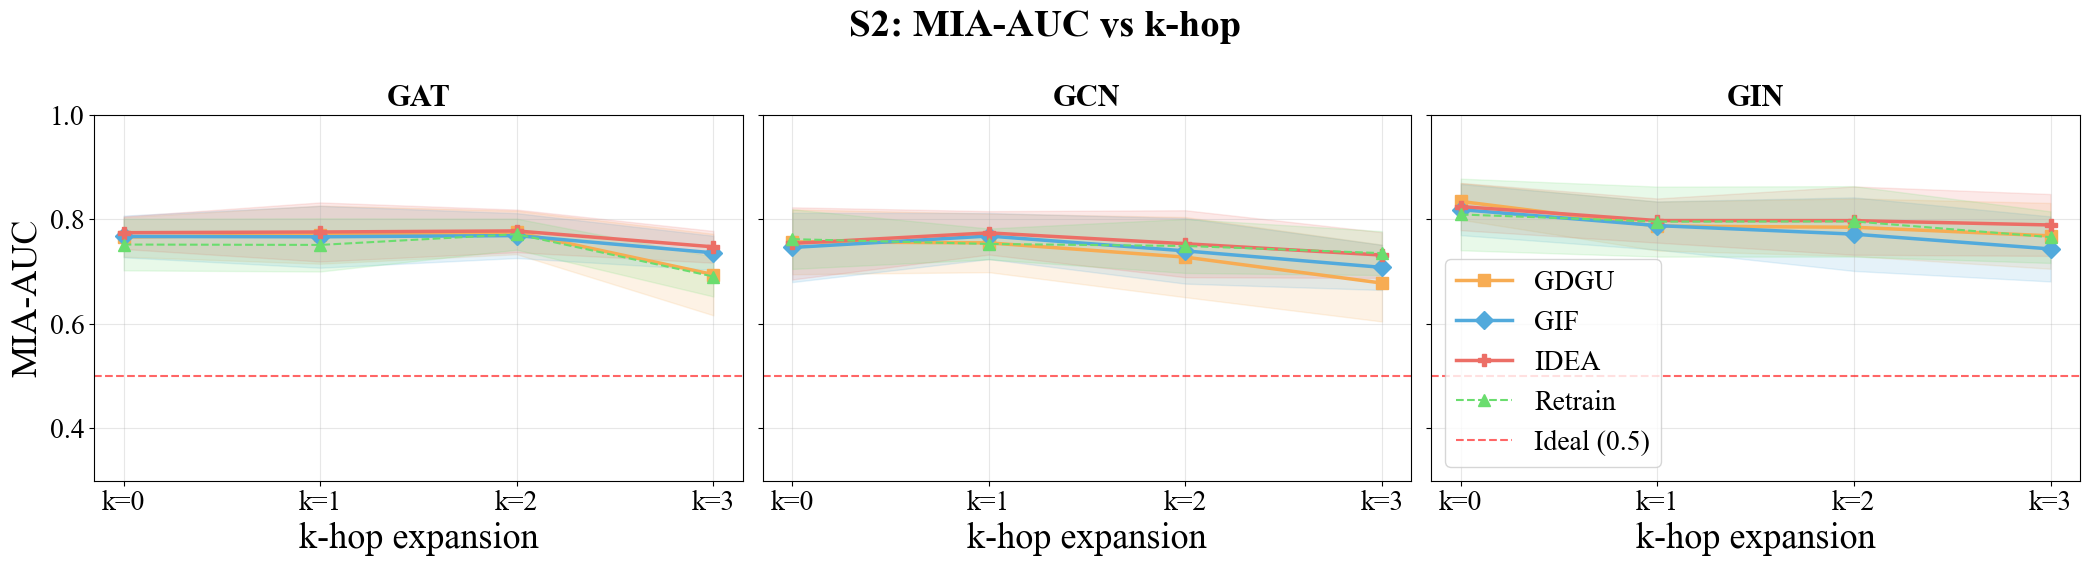

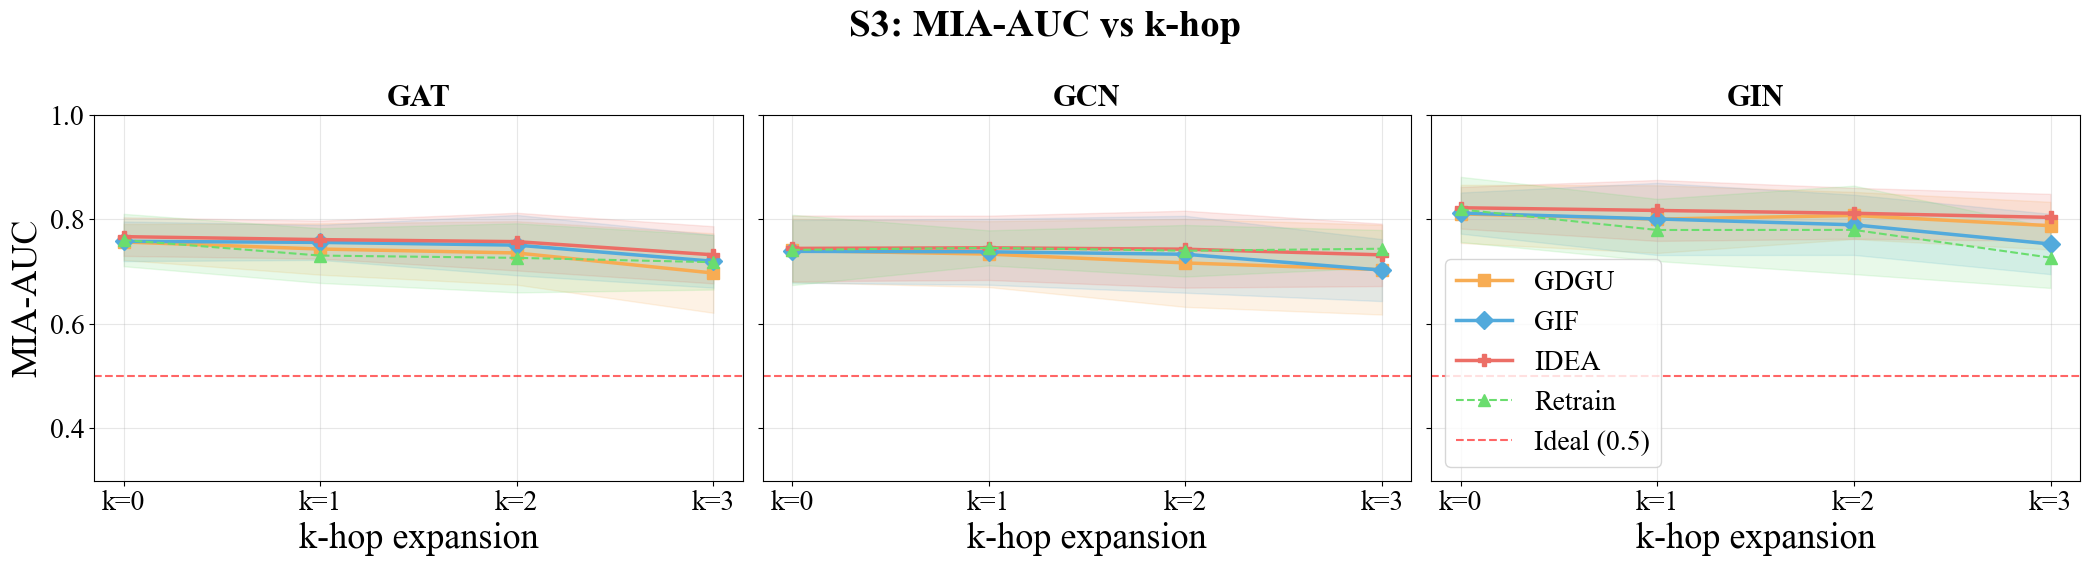

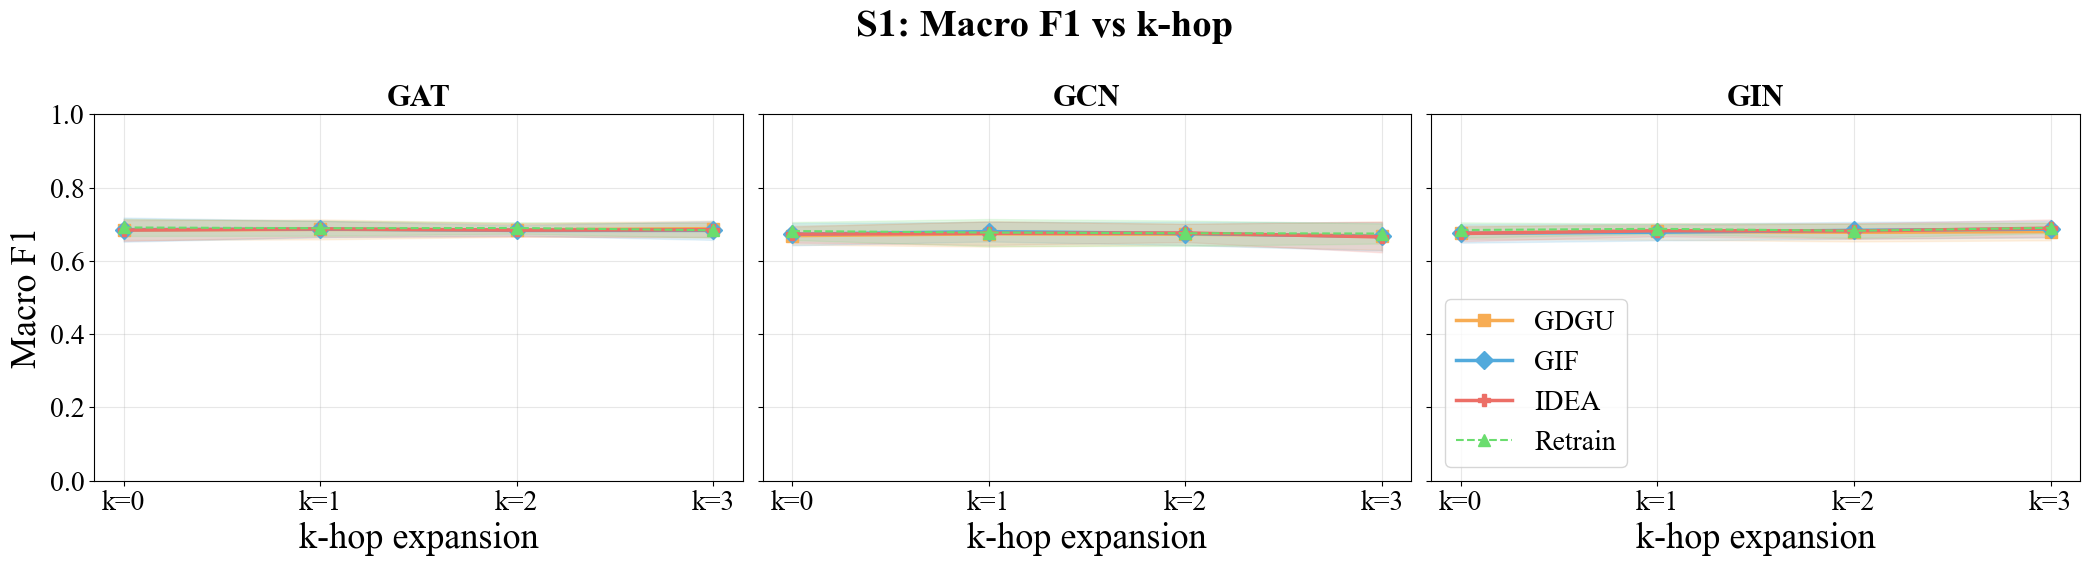

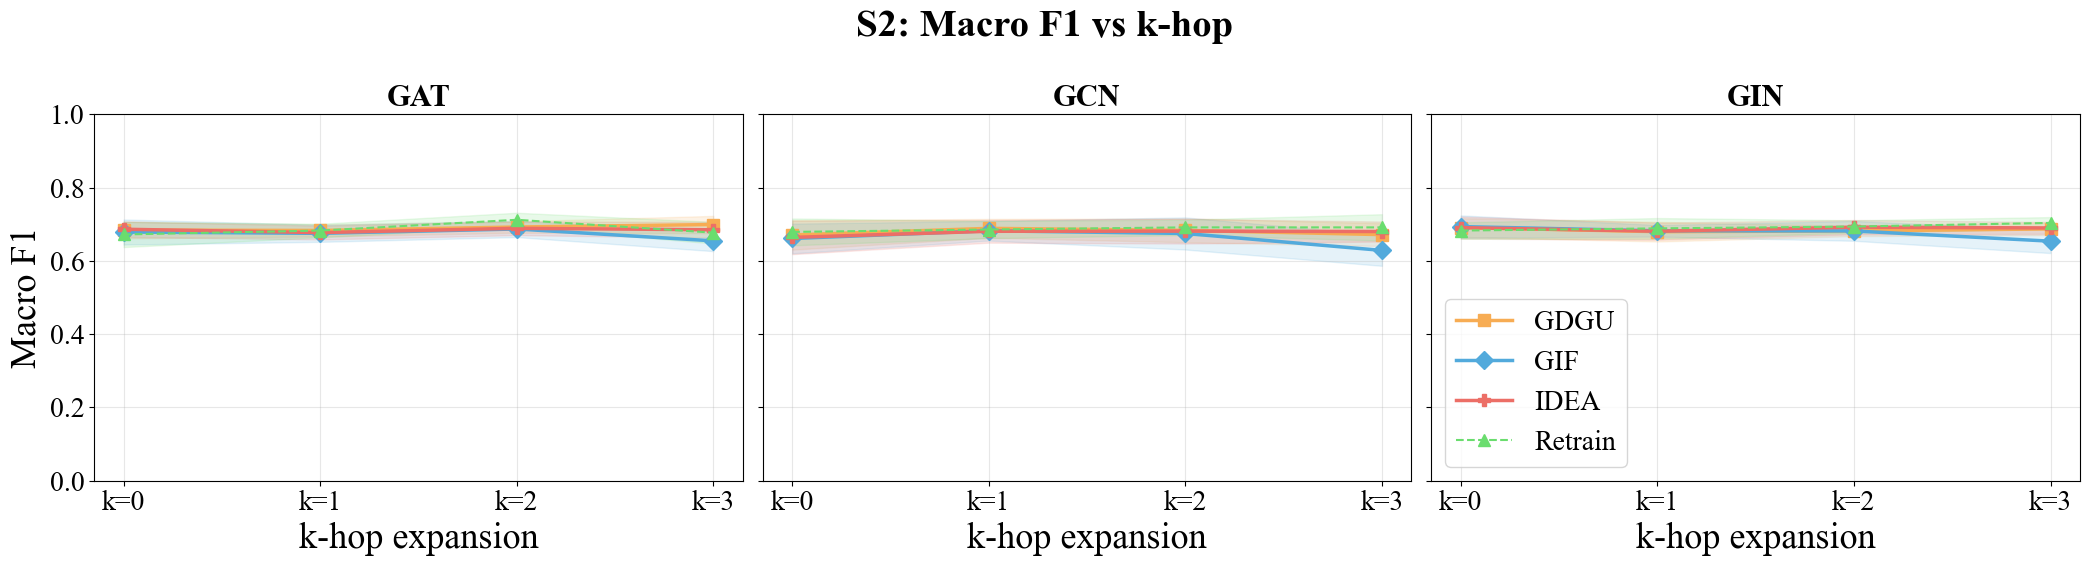

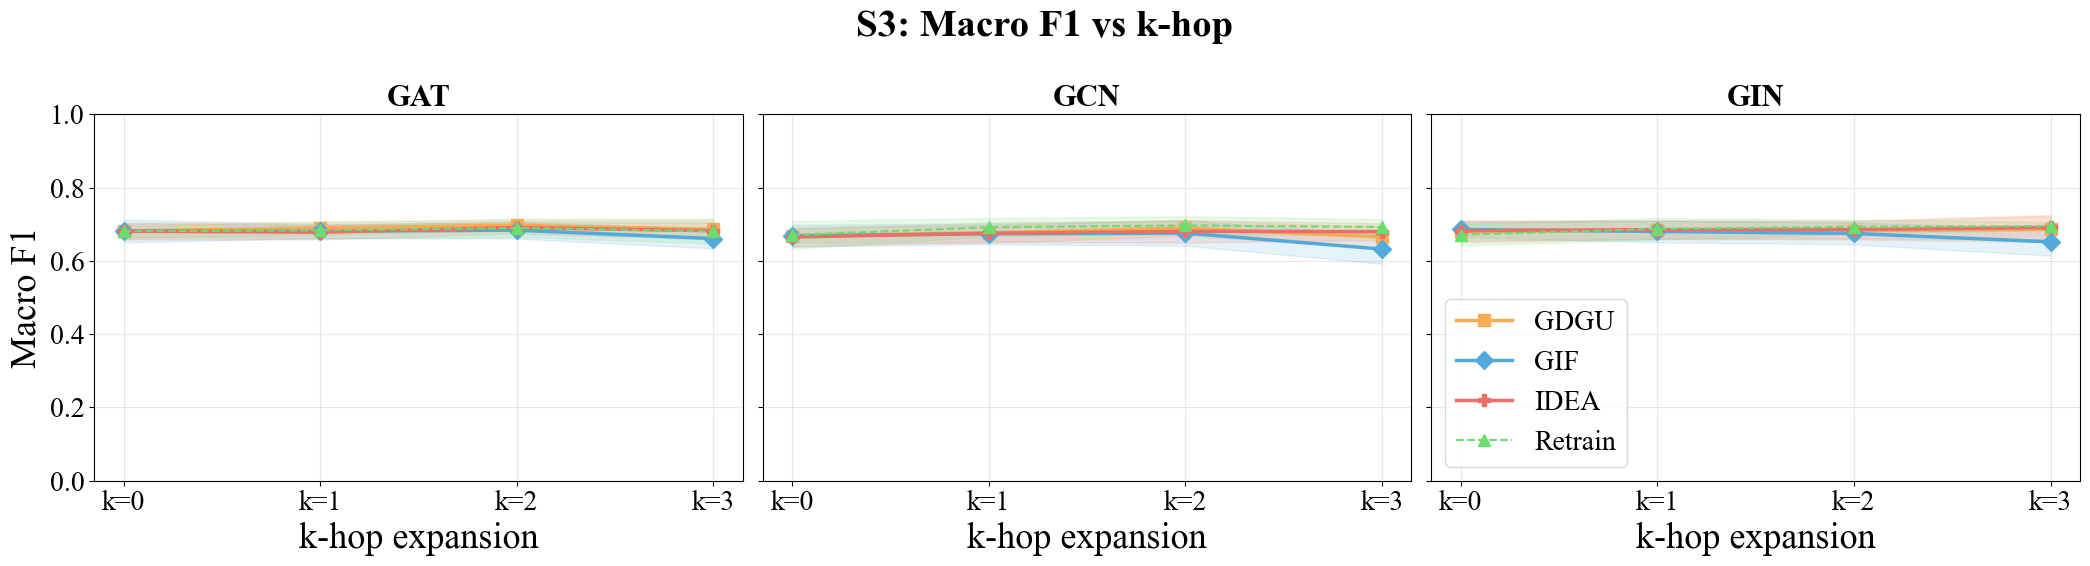

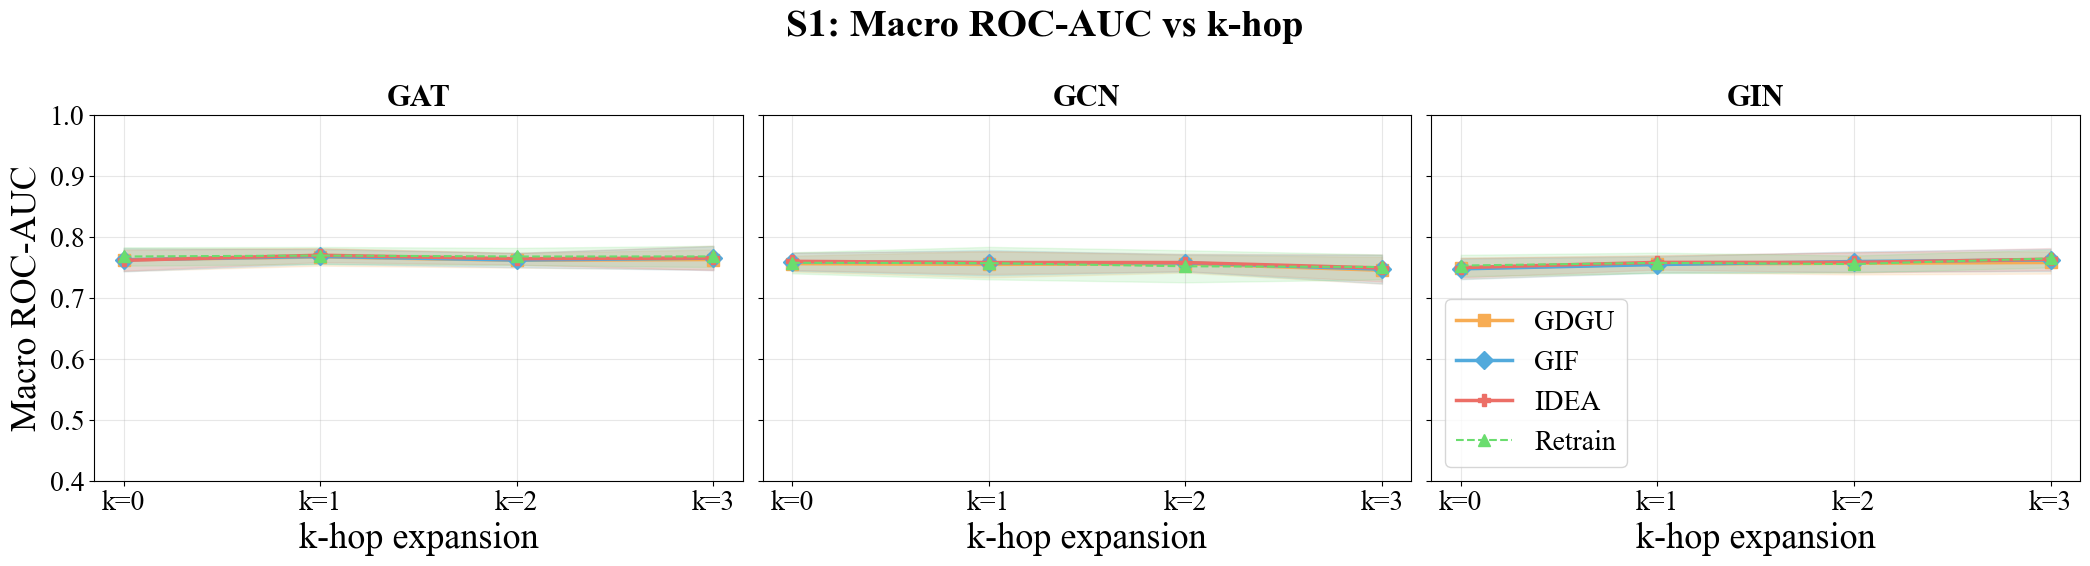

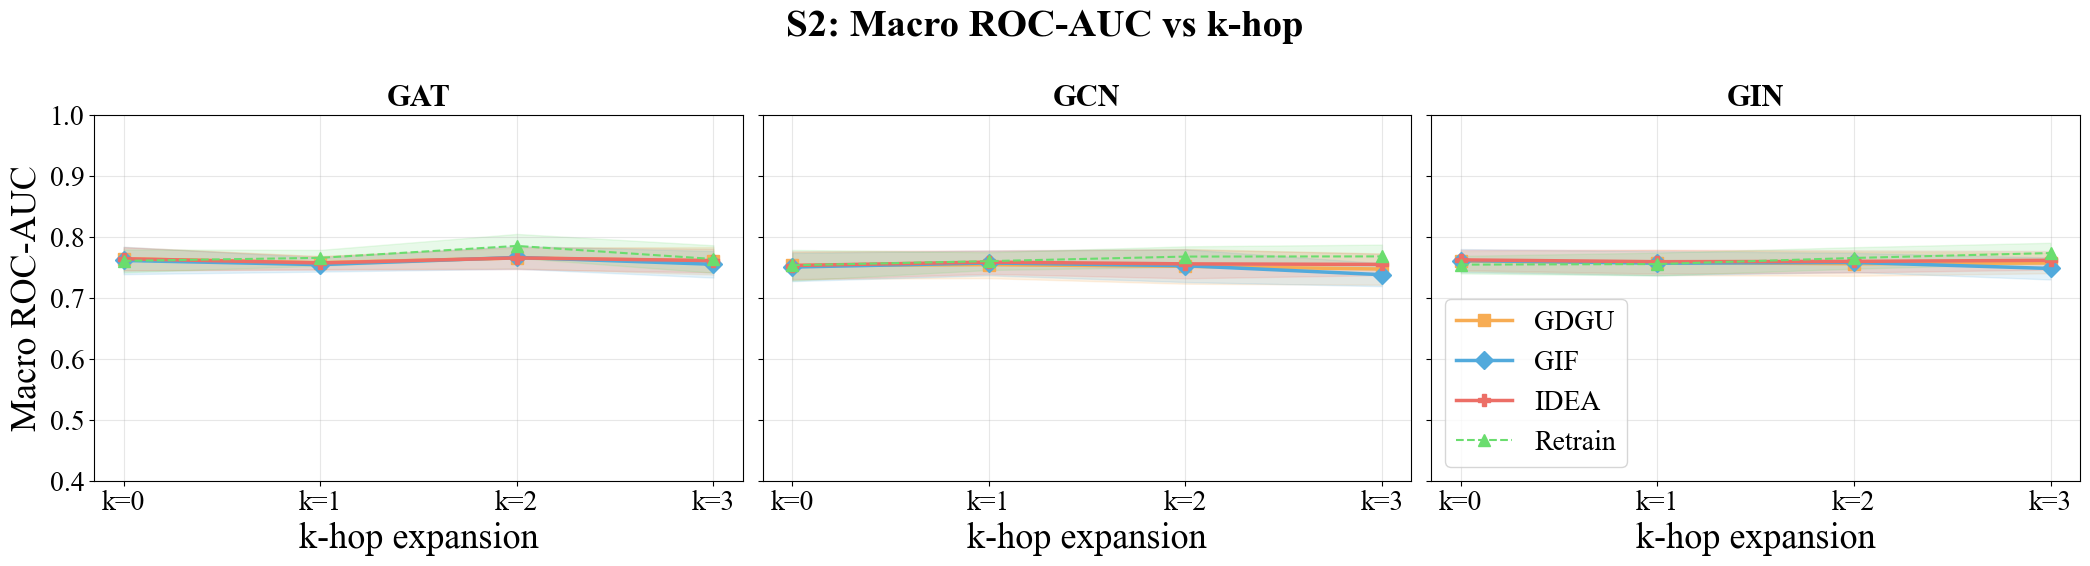

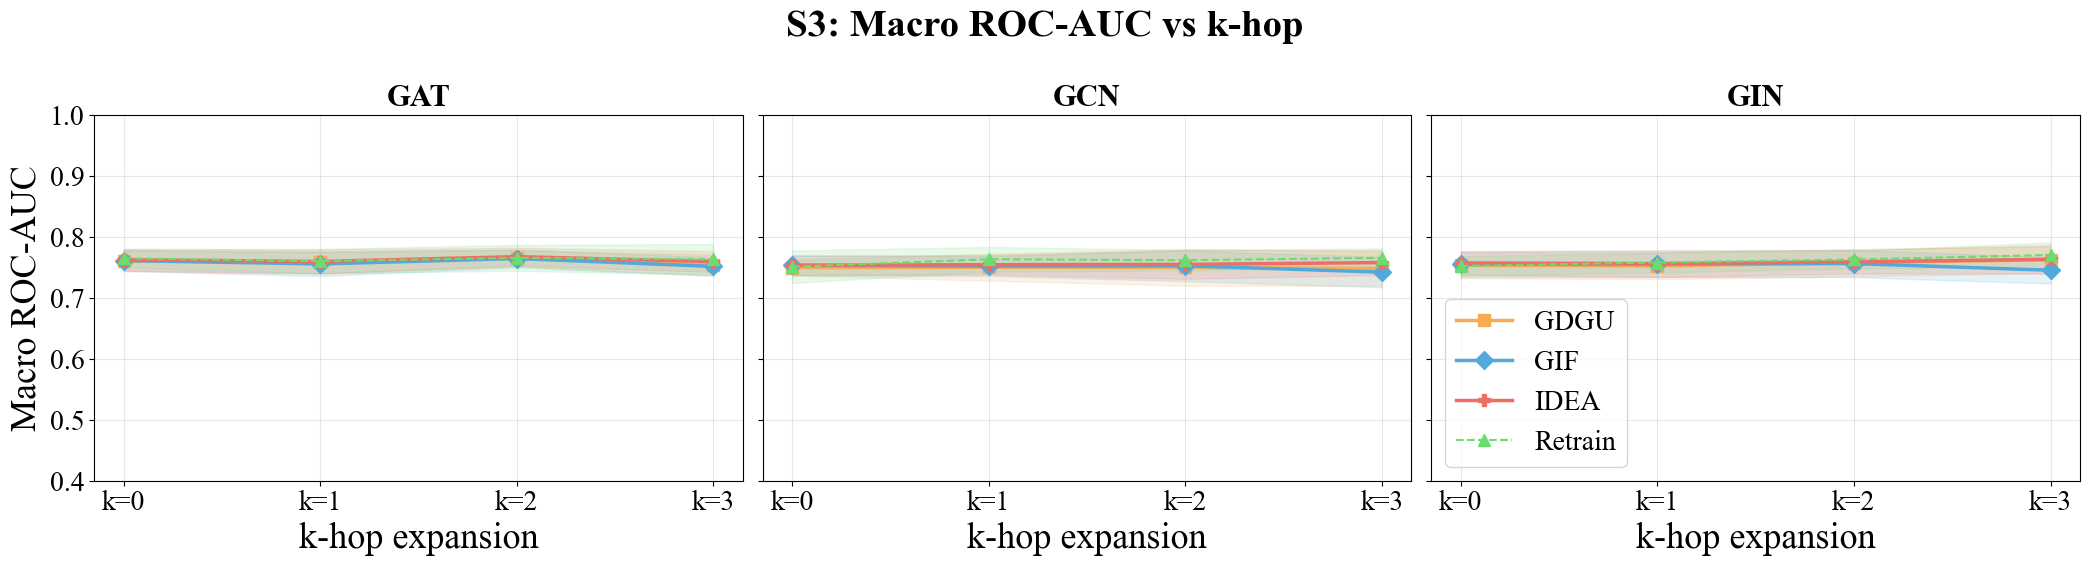

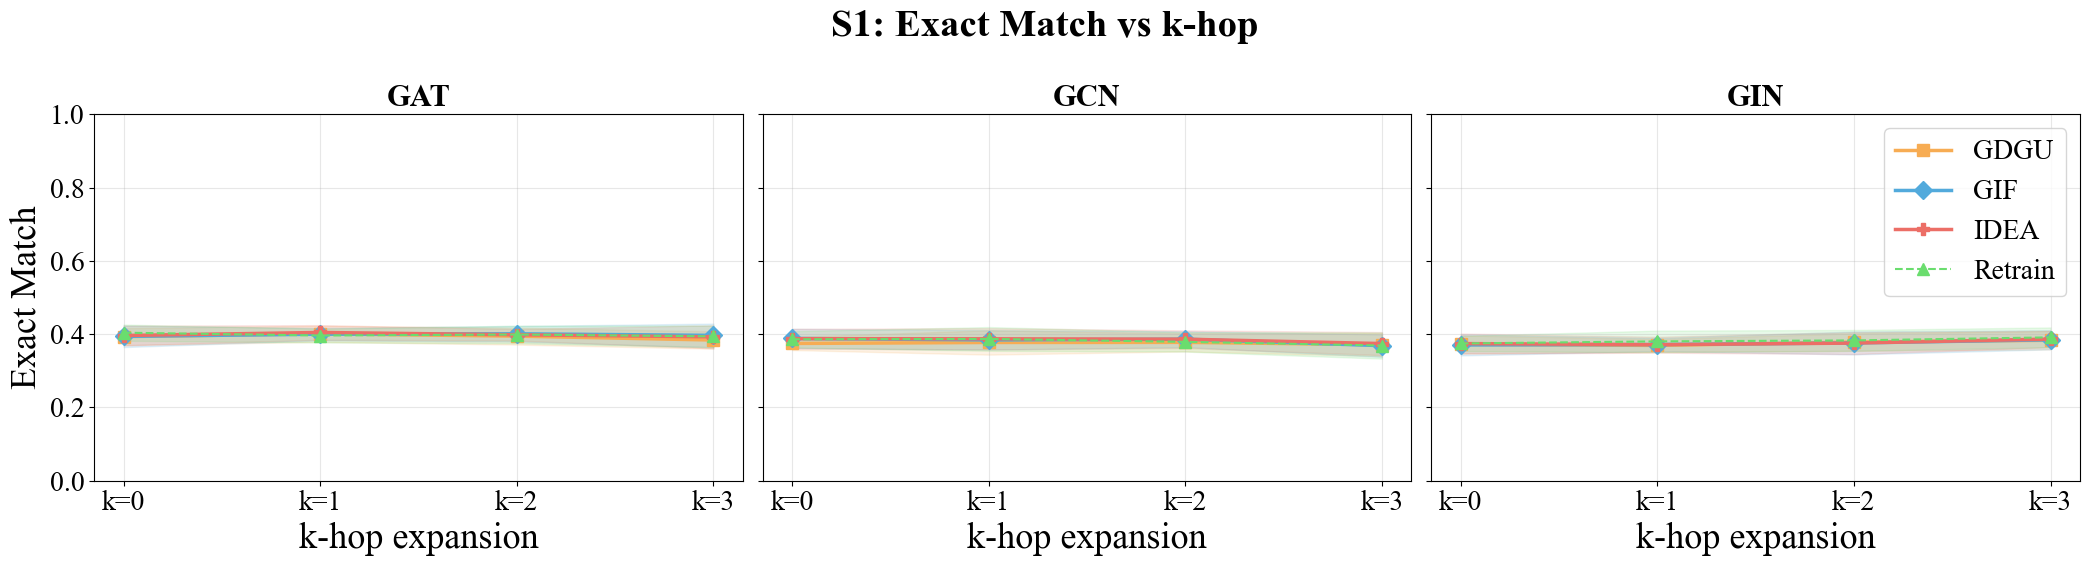

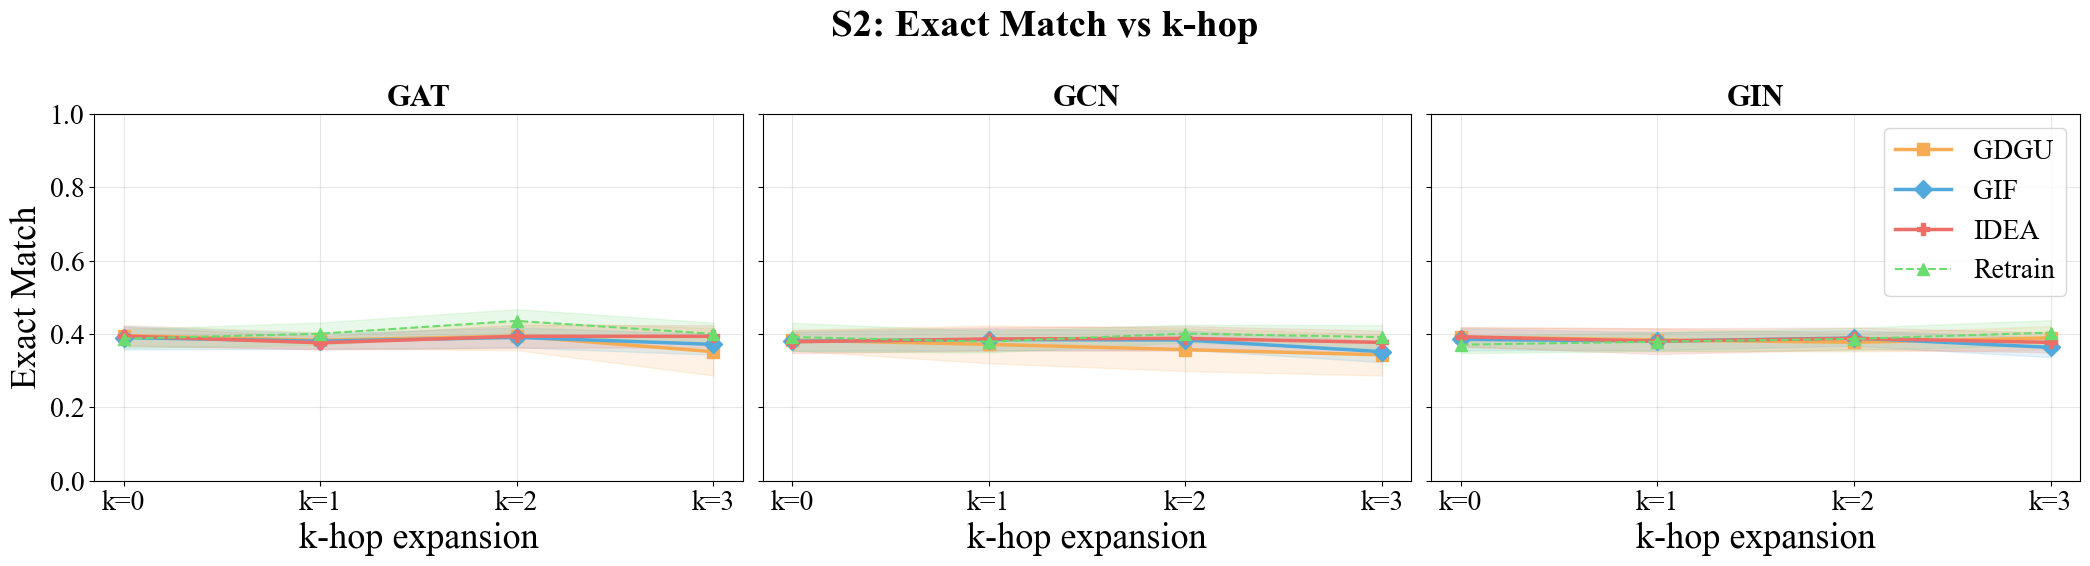

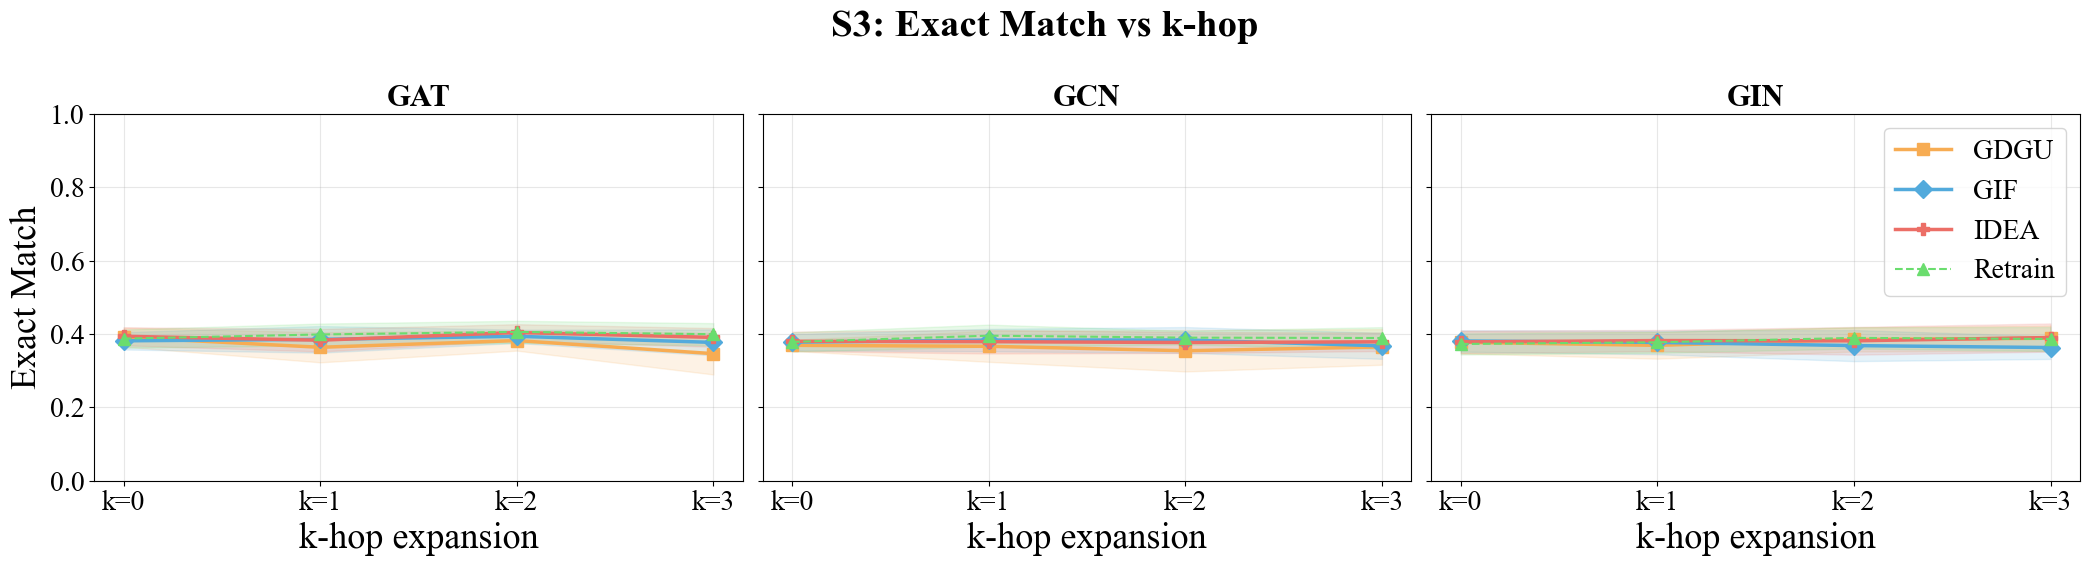

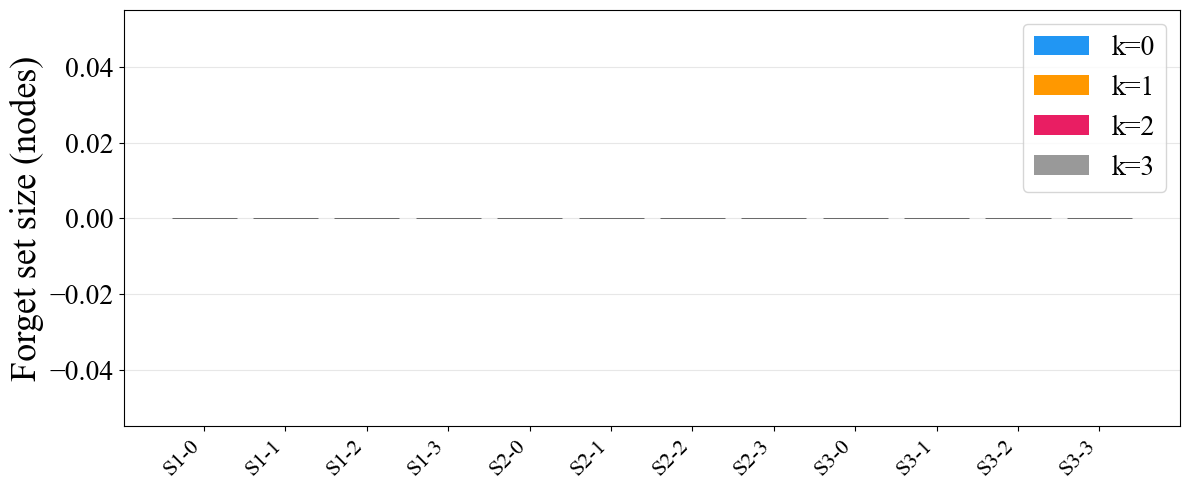


All figures saved to /home/Nanhong147/1P_WTT_NVD/Projects/4-GU_EV_loc/results/2026-04-15_01/ (prefix: 34bus_)

Figures saved to: /home/Nanhong147/1P_WTT_NVD/Projects/4-GU_EV_loc/results/2026-04-15_01/


In [3]:
# Cell 3 — Generate & save all figures to the same date folder
plot_all(df, str(RESULTS_DIR), scenarios, backbones, bus_system=BUS_SYSTEM)
print(f'\nFigures saved to: {RESULTS_DIR}/')